# Fractional Brownian Motion Parameter Estimation Using Variance Aggregation

Consider a time series of $n$, identically distributed samples,</br>

$
\begin{align}
X_1, X_2,X_3,\ldots,X_n
\end{align}
\tag{1}
$

Divide the series into $d$ smaller series of length $m$ where $md=n$.\ and let, $k = 0,1,2,3,\ldots,d-1$ and define the aggregated sum by,

$
\begin{align}
X_k^m &= \frac{1}{m}\left( X_{km+1} + X_{km+2} + \cdots + X_{km+m-1} + X_{km+m} \right) \\
&= \frac{1}{m} \left( X_{km+1} + \cdots + X_{(k+1)m} \right) \\
&= \frac{1}{m} \sum_{i=km+1}^{(k+1)m} X_i
\end{align}
\tag{2}
$

The aggregated mean is given by,

$
\begin{align}
\text{E}[X^m] &= \frac{1}{d}\sum_{i=1}^d X_i^m \\
&= \frac{1}{dm} \sum_{i=1}^d \sum_{j=im+1}^{(k+1)i} X_j \\
&= \frac{1}{n} \sum_{i=1}^n X_i
\end{align}
\tag{3}
$

and the aggregated variance by,

$
\begin{align}
\text{Var}[X^m] = \frac{1}{d} \sum_{i=1}^d\left( X^m_i - \text{E}[X^m] \right)^2
\end{align}
\tag{4}
$

This method makes use of the self similarity of fractional brownian motion. Consider the aggregated process,

$
\begin{align}
X_0^m = \frac{1}{m} \sum_{i=1}^m X_i
\end{align}
\tag{5}
$

From self similarity of fractional brownian motion,

$
\begin{align}
X_{ai} \sim a^H X_i
\end{align}
\tag{6}
$

Since the distribution of the sum of Gaussian random variables is the distribution of the last it follows that,</br> 

$
\begin{align}
X_0^m \sim \frac{1}{m} X_m \sim \frac{m^H}{m} X_1 = m^{H-1} X_1
\end{align}
\tag{7}
$

For fractional brownian noise,

$
\begin{align}
&\text{E}[\Delta Z^H_t] = 0 \\
&\text{Var}[\Delta Z^H_t] = \Delta t^{2H}
\end{align}
\tag{8}
$

$X_1$ is a single increment of brownian motion it follows that,

$
\begin{align}
\text{Var}[X_1] = \Delta t^{2H} = \sigma^2
\end{align}
\tag{9}
$

so,

$
\begin{align}
\text{Var}[X_0^m] = \text{Var}[m^{H-1} X_1] = m^{2(H-1)}\text{Var}[X_1] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{10}
$

From stationarity of it follows that,

$
\begin{align}
\text{Var}[X_k^m] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{11}
$

It follows that $H$ can be determined by using OLS on $\text{Var}[X_k^m]$ as a function of $m$.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import variance_agg, stack, curve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
Δt = 1.0
npts = 2**10
nagg = 100

def var_agg_comparison(t, fbm_noise, H):
    m_vals = [1, 10, 50]
    title = f"Aggregated Fractional Brownian Noise: Δt={Δt}, H={H}"
    labels = [f"m={m}" for m in m_vals]
    params = [{"m": m} for m in m_vals]
    func = lambda **kwargs: stats.compute_agg(t, fbm_noise, **kwargs)
    t_scan, m_scan = create_parameter_scan(func, *params)
    ylabels = [r"$X^1$", r"$X^{10}$", r"$X^{50}$"]
    stack(m_scan, t_scan, ylim=(-3.5, 3.5), ylabels=ylabels, xlabel=r"$t$", title=title, labels=labels, lw=1)

## Simulation $H=0.8$

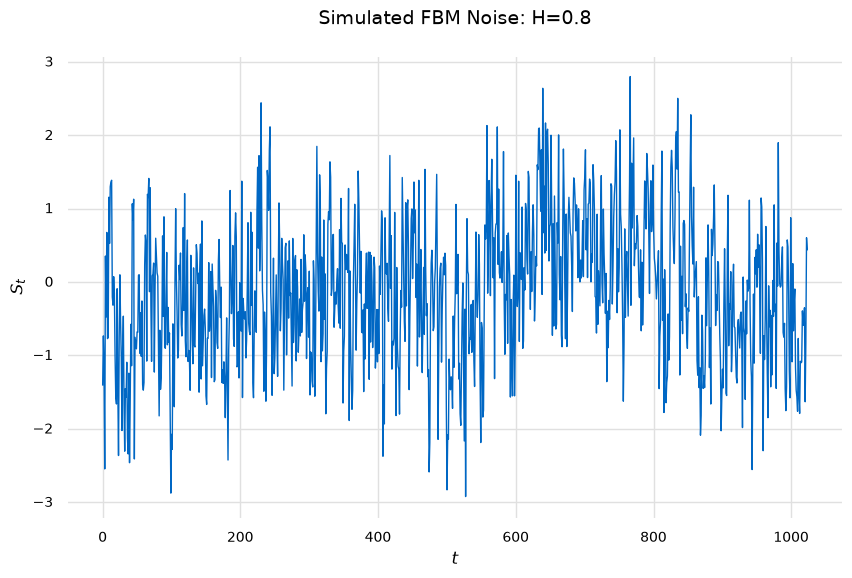

In [3]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

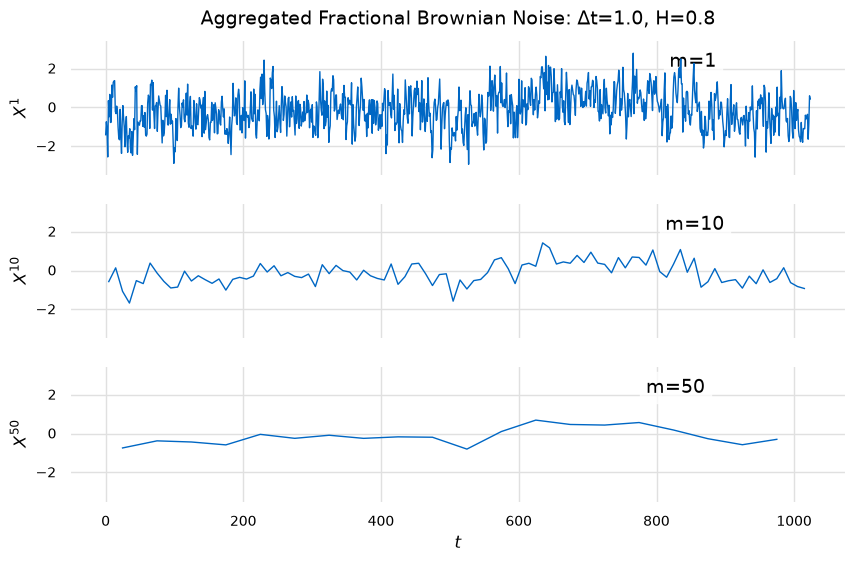

In [4]:
var_agg_comparison(t, fbm_noise, H)

In [5]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [6]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     1509.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           2.45e-61
Time:                        11:45:52   Log-Likelihood:                 181.90
No. Observations:                 100   AIC:                            -359.8
Df Residuals:                      98   BIC:                            -354.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0922      0.016     -5.724      0.000      -0.124      -0.060
x1            -0.3841      0.010    -38.851      0.000      -0.404      -0.364
==============================================================================
Omnibus:                        4.283   Durbin-Watson:                   0.730
Prob(Omnibus):                  0.117   Jarque-Bera (JB):                3.771
Skew:                           0.389   Prob(JB):                        0.152
Kurtosis:                       2.453   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.09222976039166397,
      "err": 0.016111679620571077,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "7451a568-825b-48ed-88ff-16b63909504a",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.3840668525611429,
         "err": 0.00988562748431016,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "7451a568-825b-48ed-88ff-16b63909504a",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9390320858459005,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "7451a568-825b-48ed-88ff-16b63909504a",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param"

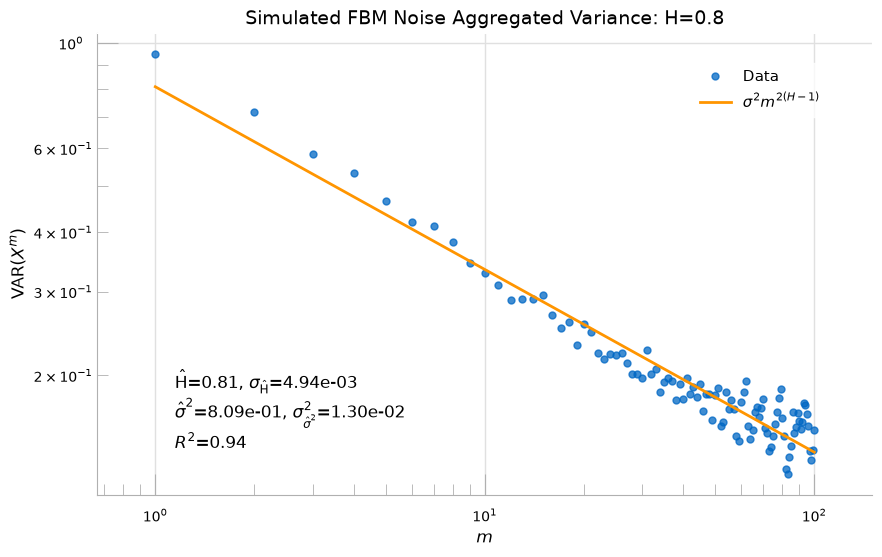

In [8]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.6$

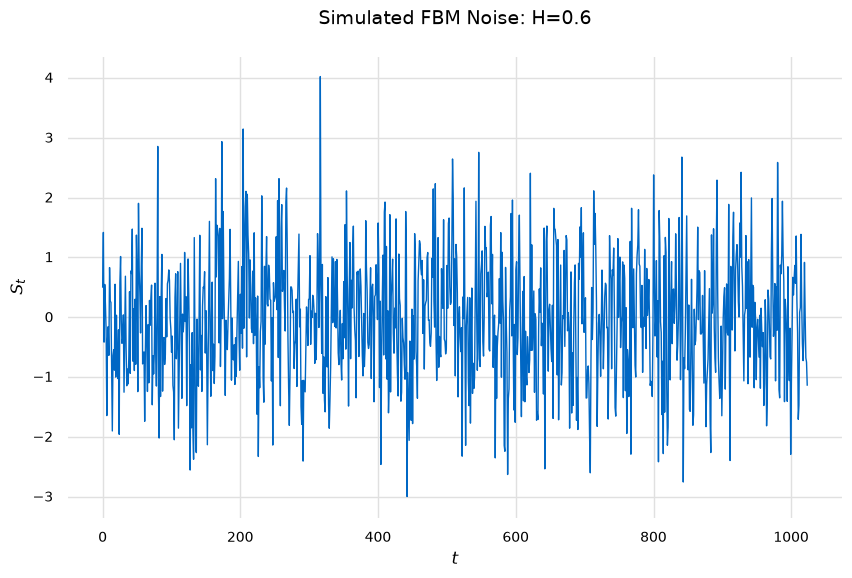

In [9]:
H = 0.6
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

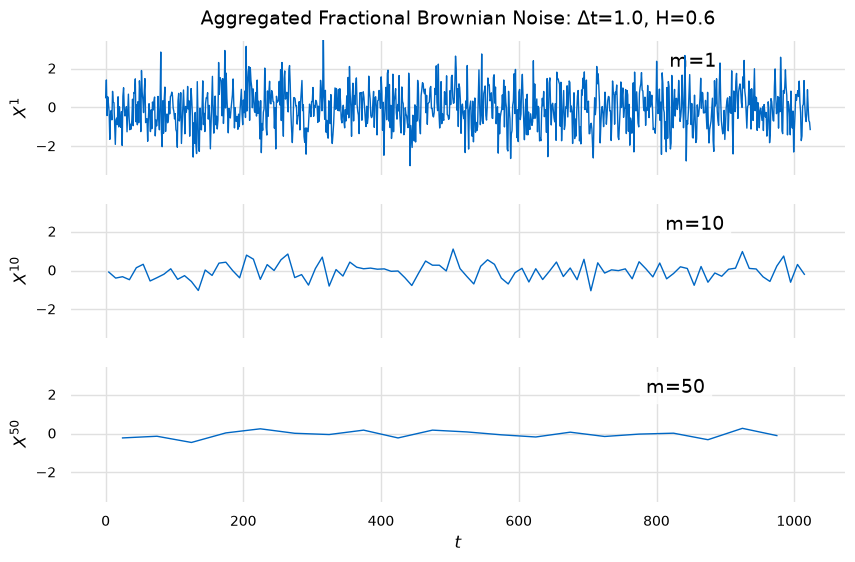

In [10]:
var_agg_comparison(t, fbm_noise, H)

In [11]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [12]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     1937.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           2.30e-66
Time:                        11:45:53   Log-Likelihood:                 102.87
No. Observations:                 100   AIC:                            -201.7
Df Residuals:                      98   BIC:                            -196.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1515      0.036      4.266      0.000       0.081       0.222
x1            -0.9590      0.022    -44.017      0.000      -1.002      -0.916
==============================================================================
Omnibus:                       25.625   Durbin-Watson:                   1.081
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.575
Skew:                          -1.043   Prob(JB):                     7.70e-11
Kurtosis:                       5.613   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.1514999423444569,
      "err": 0.035509197066908395,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "72be423c-a67a-493a-a946-813e9dfb6778",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.9590100635556689,
         "err": 0.02178734326508245,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "72be423c-a67a-493a-a946-813e9dfb6778",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9518541660769808,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "72be423c-a67a-493a-a946-813e9dfb6778",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param": 

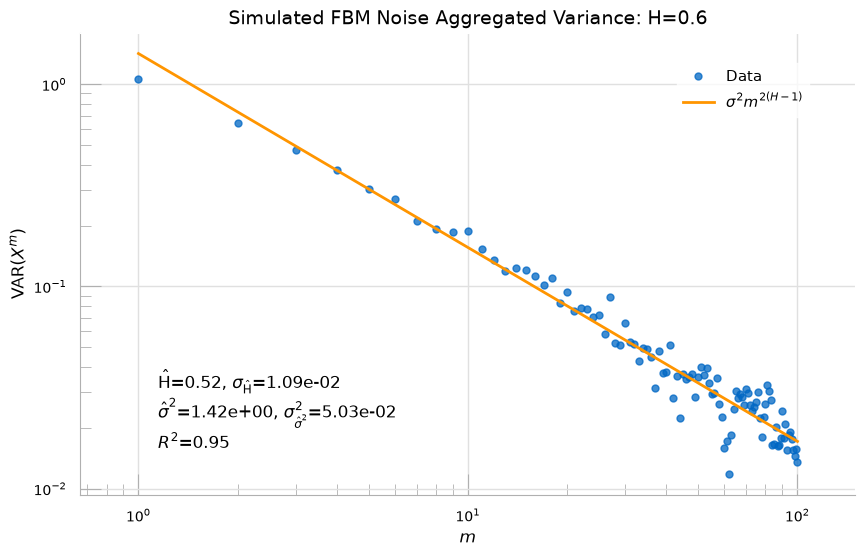

In [14]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.4$

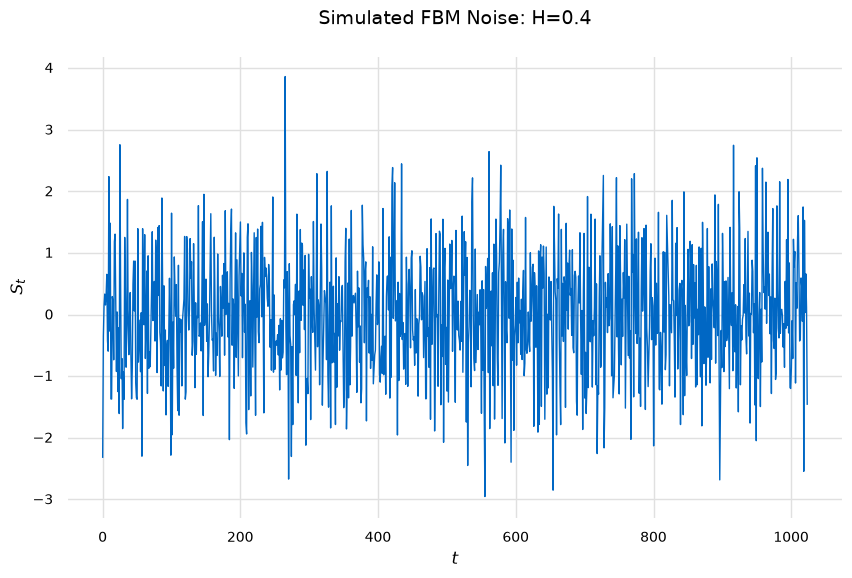

In [15]:
H = 0.4
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

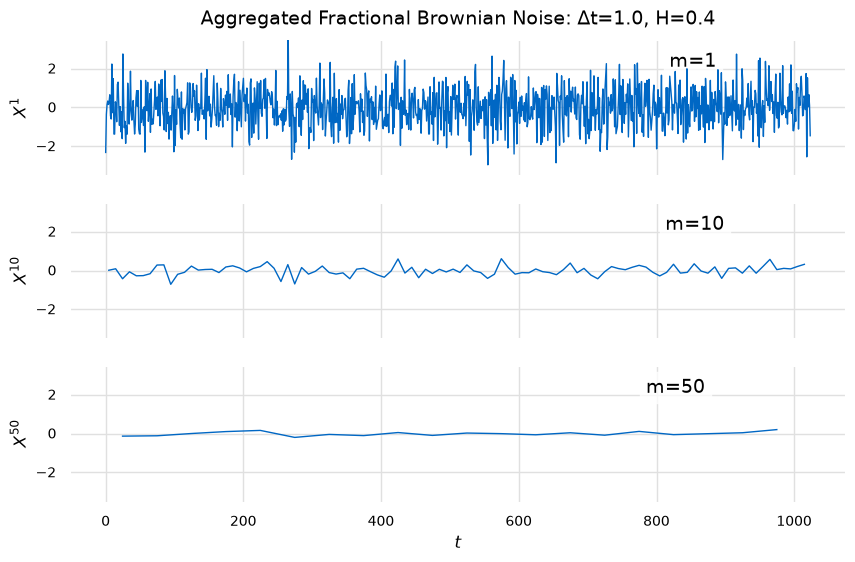

In [16]:
var_agg_comparison(t, fbm_noise, H)

In [17]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [18]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     1720.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           5.90e-64
Time:                        11:45:53   Log-Likelihood:                 74.488
No. Observations:                 100   AIC:                            -145.0
Df Residuals:                      98   BIC:                            -139.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0123      0.047      0.260      0.796      -0.081       0.106
x1            -1.2001      0.029    -41.469      0.000      -1.257      -1.143
==============================================================================
Omnibus:                       12.550   Durbin-Watson:                   1.000
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.744
Skew:                          -0.619   Prob(JB):                     0.000231
Kurtosis:                       4.576   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.012254765184355629,
      "err": 0.04716438596058142,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "faaef3ed-c302-4687-941f-7d9c66cf7428",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.2000572119658248,
         "err": 0.02893860609897169,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "faaef3ed-c302-4687-941f-7d9c66cf7428",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9460852422637281,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "faaef3ed-c302-4687-941f-7d9c66cf7428",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param":

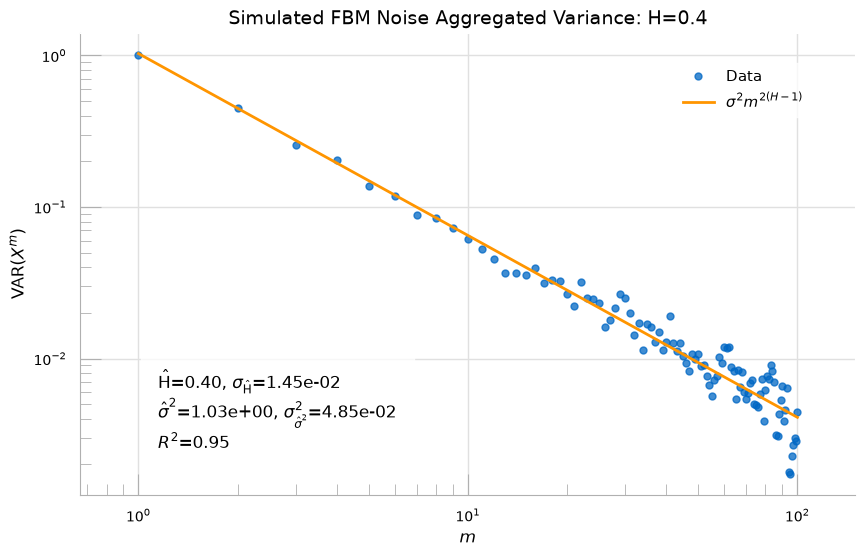

In [20]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.2$

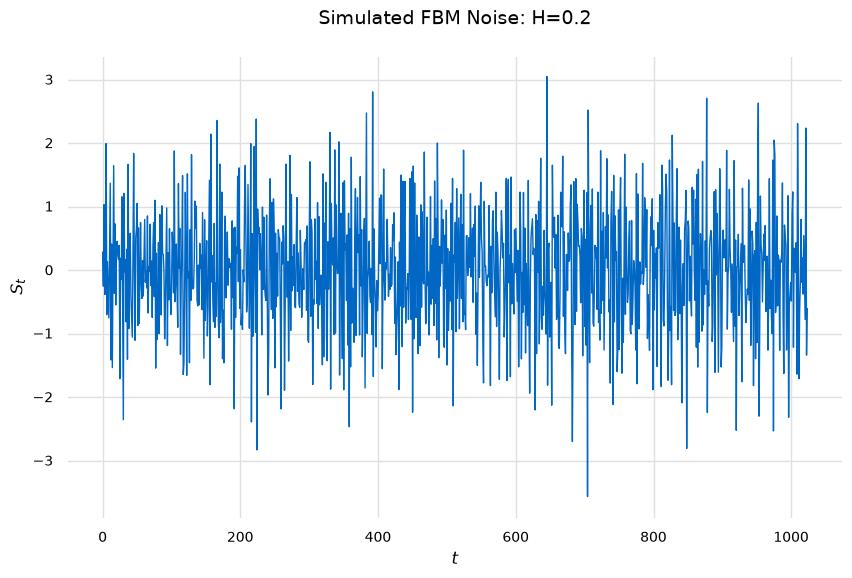

In [21]:
H = 0.2
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

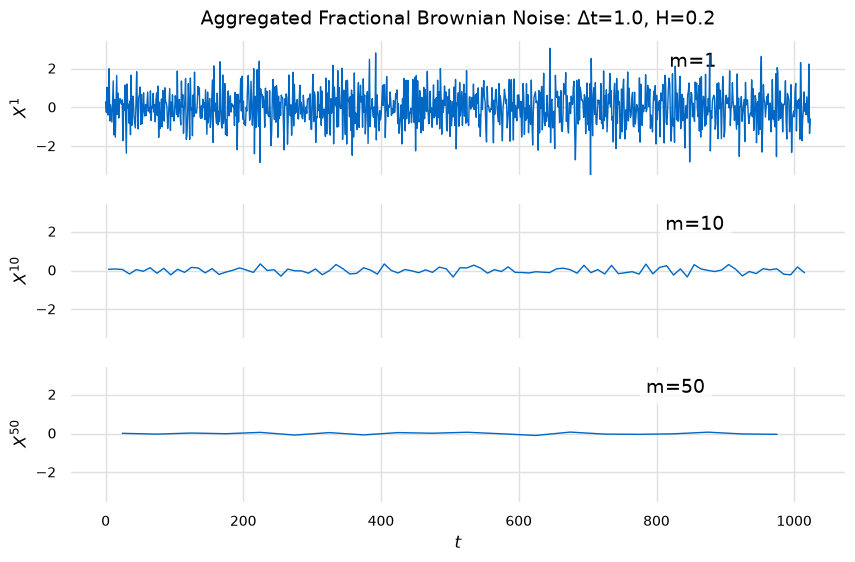

In [22]:
var_agg_comparison(t, fbm_noise, H)

In [23]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [24]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     1822.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           3.98e-65
Time:                        11:45:54   Log-Likelihood:                 49.879
No. Observations:                 100   AIC:                            -95.76
Df Residuals:                      98   BIC:                            -90.55
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0060      0.060      0.100      0.921      -0.114       0.126
x1            -1.5801      0.037    -42.690      0.000      -1.654      -1.507
==============================================================================
Omnibus:                        1.246   Durbin-Watson:                   2.091
Prob(Omnibus):                  0.536   Jarque-Bera (JB):                0.738
Skew:                          -0.031   Prob(JB):                        0.691
Kurtosis:                       3.416   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.006012960753931082,
      "err": 0.06032377344024504,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "7c942ec6-60d3-4b1e-8d15-2ca939293949",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.5800780640350727,
         "err": 0.0370127985859893,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "7c942ec6-60d3-4b1e-8d15-2ca939293949",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9489700278076661,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "7c942ec6-60d3-4b1e-8d15-2ca939293949",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param": 

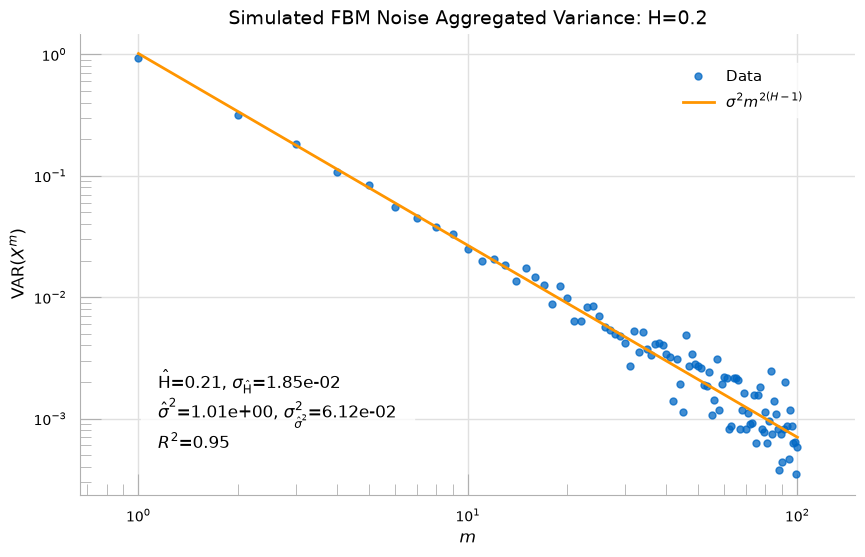

In [26]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")